# Clasificación de Sentimientos con BERT y Hugging Face

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arlexpin/icesi-nlp/Entregables/Sesion 4/Work4.ipynb)

En este notebook construiremos un clasificador de sentimientos en inglés a partir de un modelo BERT preentrenado disponible en Hugging Face. La idea es reutilizar un encoder ya entrenado sobre lenguaje general y adaptarlo a una tarea supervisada pequeña mediante transferencia de aprendizaje.

El flujo del ejercicio será: limpiar y reagrupar etiquetas del dataset, inspeccionar la distribución de clases y la longitud de los textos, tokenizar con el tokenizer original de BERT, entrenar un clasificador simple, probar una cabeza personalizada y finalmente comparar con fine tuning completo.

#### Referencias
- Dataset: sentimentdataset.csv
- [Google BERT base uncased](https://huggingface.co/google-bert/bert-base-uncased)
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](http://arxiv.org/abs/1810.04805)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/en/index)
- [Hugging Face Datasets](https://huggingface.co/docs/datasets/en/index)
- [Hugging Face Evaluate](https://huggingface.co/docs/evaluate/en/index)

In [1]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

C:\Users\apapa\AppData\Local\Temp\ipykernel_54100\2396000874.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [2]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets 'transformers[torch]' sentence-transformers torchinfo evaluate

"test" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"test" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"test" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"test" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"test" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


### Cargando y normalizando el dataset
El archivo contiene textos cortos en inglés con etiquetas de sentimiento. Antes de entrenar conviene limpiar valores vacíos, unificar variantes semánticamente equivalentes y reagrupar clases muy raras en una categoría residual para que el problema de clasificación sea más estable.

Esta parte del notebook deja el conjunto en un formato consistente para modelado y evita que el clasificador aprenda de etiquetas casi sin ejemplos.

In [3]:
import pandas as pd
import warnings
import os
import re
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Resuelve la ruta del CSV relativa al notebook, independientemente del cwd del kernel.
_nb_file = globals().get('__vsc_ipynb_file__', None)
_nb_dir = os.path.dirname(os.path.abspath(_nb_file)) if _nb_file else os.getcwd()
dataset_file = os.path.join(_nb_dir, 'sentimentdataset.csv')

print("[Inicio] Preparando carga y limpieza del dataset...")
print(f"[Info] Buscando dataset en: {dataset_file}")

if not os.path.exists(dataset_file):
    print(f"[Error] No se encontró el archivo '{dataset_file}'.")
    df_raw = pd.DataFrame(columns=['Text', 'Sentiment'])
    dataset = []
else:
    print(f"[1/5] Cargando dataset...")
    df_raw = pd.read_csv(dataset_file)
    df_raw = df_raw[['Text', 'Sentiment']].copy()
    print(f"Registros iniciales: {len(df_raw)}")

    df_raw['Text'] = df_raw['Text'].fillna('').astype(str).str.strip()
    df_raw['Sentiment'] = df_raw['Sentiment'].fillna('').astype(str).str.strip()
    print("[2/5] Limpieza básica aplicada en columnas Text y Sentiment.")

    def normalize_sentiment_label(label: str) -> str:
        label = str(label).strip().lower()
        label = re.sub(r"[^a-z\s\-]", "", label)
        label = label.replace('-', ' ')
        label = re.sub(r"\s+", " ", label).strip()

        alias_map = {
            'positive': {'joy', 'happy', 'happiness', 'elation', 'euphoria', 'enthusiasm', 'amusement', 'overjoyed', 'playfuljoy', 'festivejoy', 'zest', 'celebration', 'contentment', 'serenity', 'positivity', 'love', 'affection', 'adoration', 'gratitude', 'grateful', 'appreciation', 'compassion', 'compassionate', 'empathetic', 'kindness', 'friendship', 'romance', 'heartwarming', 'touched', 'connection', 'surprise', 'awe', 'amazement', 'wonder', 'wonderment', 'enchantment', 'captivation', 'marvel', 'thrill', 'excitement', 'exhilaration', 'ecstasy', 'bliss', 'delight', 'pleasure', 'satisfaction', 'pride', 'accomplishment', 'triumph', 'optimism', 'hope', 'inspiration', 'motivation', 'curiosity', 'curious', 'interest', 'intrigue', 'fascination', 'fascinated', 'engagement', 'engaged', 'intrigued'},
            'negative': {'fear', 'fearful', 'anxiety', 'apprehensive', 'intimidation', 'helplessness', 'pressure', 'suffering', 'emotionalstorm','sad', 'sadness', 'grief', 'despair', 'melancholy', 'heartbreak', 'sorrow', 'loss', 'loneliness', 'disappointment', 'devastated', 'desolation', 'heartache', 'ruins', 'darkness', 'exhaustion', 'lostlove', 'solitude', 'anger', 'hate', 'frustration', 'frustrated', 'bitterness', 'bitter', 'resentment', 'betrayal', 'disgust', 'regret', 'nostalgia', 'guilt', 'shame', 'embarrassment', 'humiliation', 'jealousy', 'envy', 'resentment', 'resentful', 'disapproval', 'disapproving', 'contempt', 'contemptuous', 'disdain', 'disdainful'},
        }

        for canonical_label, aliases in alias_map.items():
            if label in aliases:
                return canonical_label
        return label

    print("[3/5] Normalizando etiquetas de sentimiento...")
    df_raw['Sentiment_norm'] = df_raw['Sentiment'].apply(normalize_sentiment_label)
    df_raw = df_raw[(df_raw['Text'] != '') & (df_raw['Sentiment_norm'] != '')].copy()
    normalized_counts = df_raw['Sentiment_norm'].value_counts()
    print(f"Etiquetas normalizadas detectadas: {normalized_counts.shape[0]}")

    print("[4/5] Agrupando clases raras en 'other'...")
    min_samples_per_class = 10
    valid_classes = normalized_counts[normalized_counts >= min_samples_per_class].index
    df_raw['Sentiment'] = df_raw['Sentiment_norm'].where(
        df_raw['Sentiment_norm'].isin(valid_classes), 'other'
    )

    final_counts = df_raw['Sentiment'].value_counts()
    dataset = df_raw[['Text', 'Sentiment']].to_dict('records')

    print("[5/5] Dataset listo para modelado.")
    print(f"Total de registros finales: {len(dataset)}")
    print(f"Clases: {final_counts.shape[0]}")
    print(final_counts)

df_raw[['Text', 'Sentiment']].head()

[Inicio] Preparando carga y limpieza del dataset...
[Info] Buscando dataset en: c:\Users\apapa\GitHub\icesi-nlp\Entregables\Sesion 4\sentimentdataset.csv
[1/5] Cargando dataset...
Registros iniciales: 732
[2/5] Limpieza básica aplicada en columnas Text y Sentiment.
[3/5] Normalizando etiquetas de sentimiento...
Etiquetas normalizadas detectadas: 98
[4/5] Agrupando clases raras en 'other'...
[5/5] Dataset listo para modelado.
Total de registros finales: 732
Clases: 4
Sentiment
positive    334
other       227
negative    153
neutral      18
Name: count, dtype: int64


,Text,Sentiment
0,Enjoying a beautiful day at the park!,positive
1,Traffic was terrible this morning.,negative
2,Just finished an amazing workout! 💪,positive
3,Excited about the upcoming weekend getaway!,positive
4,Trying out a new recipe for dinner tonight.,neutral


In [4]:
import numpy as np
from typing import Any, cast

id2category = dict(enumerate(cast(Any, df_raw)['Sentiment'].unique()))
category2id = {v: k for k, v in id2category.items()}

df = cast(Any, df_raw)
df['category_id'] = df['Sentiment'].map(category2id)
df = df[['Text', 'Sentiment', 'category_id']].sample(frac=1).reset_index(drop=True)
df.head()

,Text,Sentiment,category_id
0,Survived a group project without any drama. Mi...,positive,0
1,Whimsical delight in a world of fairy tales an...,other,3
2,Helplessness sinks in as challenges pile up.,negative,1
3,"Reflecting on a lifetime of memories, each wri...",positive,0
4,"Soaring on the wings of a free spirit, unburde...",other,3


A continuación exploramos algunas propiedades básicas del dataset ya limpio.

Primero revisamos la distribución de las clases para verificar si el problema quedó razonablemente balanceado después de la normalización.

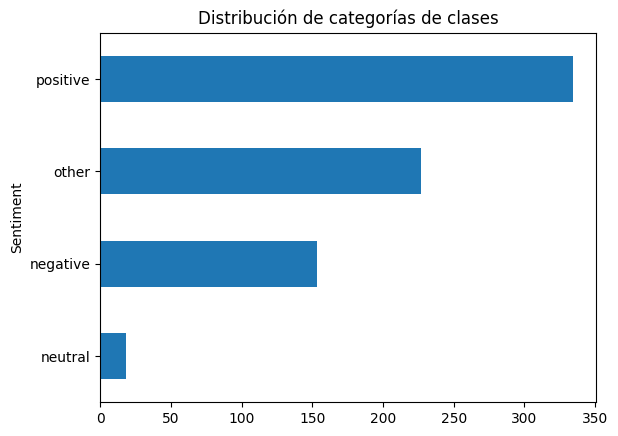

In [5]:
import matplotlib.pyplot as plt

df.Sentiment.value_counts(ascending=True).plot.barh()
plt.title('Distribución de categorías de clases')
plt.show()

In [6]:
df.Sentiment.value_counts()

Sentiment
positive    334
other       227
negative    153
neutral      18
Name: count, dtype: int64

Ahora observamos la longitud de los textos por categoría. Esto nos ayuda a decidir un tamaño máximo de secuencia razonable para tokenización, evitando padding innecesario y reduciendo costo computacional.

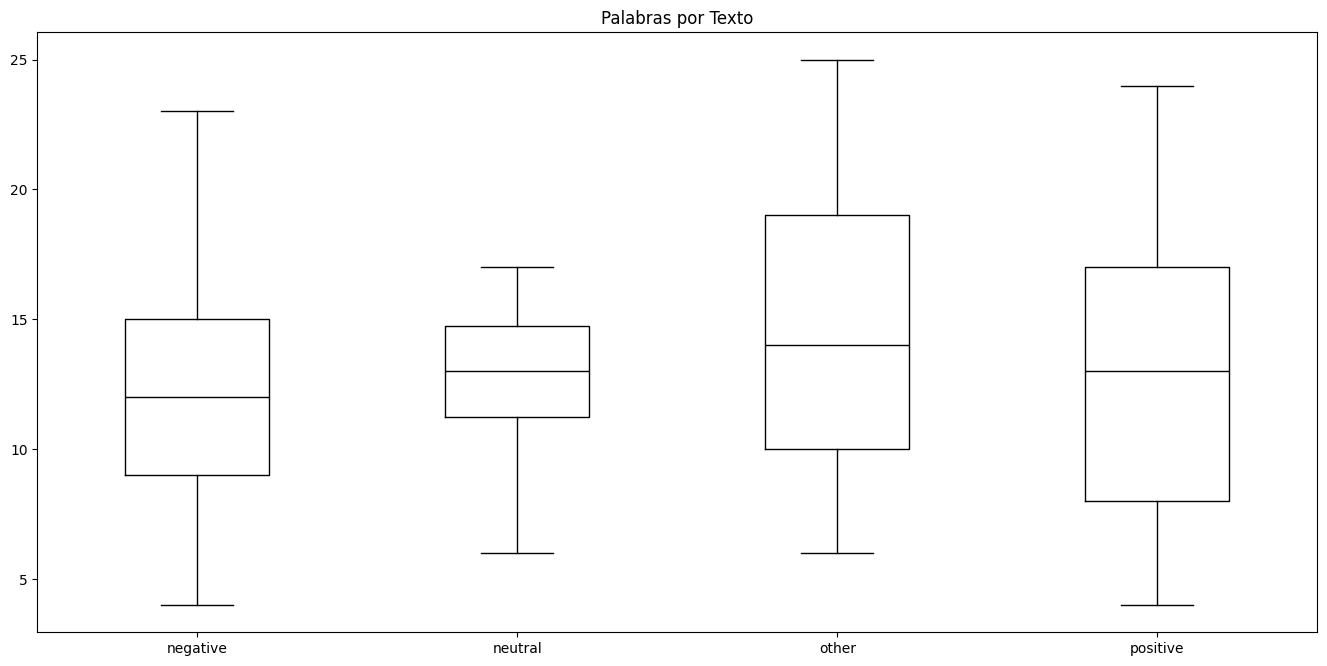

In [7]:
df['Palabras por Texto'] = df['Text'].str.split().apply(len)
df.boxplot('Palabras por Texto', by='Sentiment', grid=False, showfliers=False, color='black', figsize=(16, 8))
plt.suptitle('')
plt.xlabel('')
plt.show()

Aunque hay variación entre categorías, en este ejercicio los textos son cortos. Por eso no tiene sentido tokenizar a 512 posiciones como en tareas de documentos largos: basta con un máximo pequeño que cubra la mayoría de frases sin desperdiciar memoria ni tiempo de entrenamiento.

In [8]:
df.groupby('Sentiment')['Palabras por Texto'].median()

Sentiment
negative    12.0
neutral     13.0
other       14.0
positive    13.0
Name: Palabras por Texto, dtype: float64

La mediana de longitud ronda las 13 palabras. Con esa referencia, un máximo de 16 o 32 tokens suele ser suficiente para este dataset y resulta mucho más eficiente que usar secuencias largas.

In [9]:
from datasets import Dataset

# Si viene como list[dict], lo convertimos a Hugging Face Dataset
if isinstance(dataset, list):
    dataset = Dataset.from_list(dataset)

# Alinear nombres de columnas con el resto del notebook
# Asegura que `dataset` exista también para análisis estático/ejecución fuera de orden
if 'dataset' not in globals() or dataset is None:
    if 'df_raw' in globals() and {'Text', 'Sentiment'}.issubset(df_raw.columns):
        dataset = Dataset.from_pandas(df_raw[['Text', 'Sentiment']].copy(), preserve_index=False)
    else:
        dataset = Dataset.from_dict({'Text': [], 'Sentiment': []})

if 'Text' in dataset.column_names:
    dataset = dataset.rename_column('Text', 'text')
if 'Sentiment' in dataset.column_names:
    dataset = dataset.rename_column('Sentiment', 'category')

# Reinicia formato si ya se había seteado antes
dataset.reset_format()

dataset

Dataset({
    features: ['text', 'category'],
    num_rows: 732
})

### Definiendo el tokenizer y el checkpoint base

Cuando se reutiliza un modelo preentrenado, el tokenizer debe ser el correspondiente a ese mismo checkpoint. De lo contrario, los ids de entrada dejan de representar lo que el encoder espera y el modelo pierde coherencia semántica.

En este caso usaremos BERT base uncased en inglés. Es un modelo generalista, preentrenado sobre corpus en inglés, y sirve como punto de partida para clasificación supervisada.

In [10]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained("bert-base-uncased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Si al cargar el checkpoint aparecen mensajes sobre parámetros `UNEXPECTED` o `MISSING`, no necesariamente es un error. Es normal cuando se toma un BERT base preentrenado y se adapta a una arquitectura de clasificación: el encoder reutiliza pesos del preentrenamiento y la cabeza de clasificación se inicializa aparte.

In [11]:
import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
inputs = tokenizer("hello world!!!", max_length=10, truncation=True, padding='max_length', return_tensors='pt')

print(f"Input Shapes & Types:")
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

model_ckpt = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=len(category2id)
).to(device)

# Congelamos los pesos del modelo base para usarlo como featurizer solamente, solo va a aprender la capa de clasificación
for param in model.base_model.parameters():
    param.requires_grad = False
    
  
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))



Input Shapes & Types:
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 4]                    --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,440,896)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

Aquí vemos la estructura de `BertForSequenceClassification`: un encoder BERT como backbone y una capa final de clasificación. En este primer experimento congelamos el encoder para usarlo como featurizer, de modo que solo la cabeza final aprenda con nuestro dataset.

Este enfoque reduce costo de entrenamiento y sirve como línea base antes de probar variantes más flexibles.

In [12]:
modules = [m for m, _ in model.named_modules()]
modules

['',
 'bert',
 'bert.embeddings',
 'bert.embeddings.word_embeddings',
 'bert.embeddings.position_embeddings',
 'bert.embeddings.token_type_embeddings',
 'bert.embeddings.LayerNorm',
 'bert.embeddings.dropout',
 'bert.encoder',
 'bert.encoder.layer',
 'bert.encoder.layer.0',
 'bert.encoder.layer.0.attention',
 'bert.encoder.layer.0.attention.self',
 'bert.encoder.layer.0.attention.self.query',
 'bert.encoder.layer.0.attention.self.key',
 'bert.encoder.layer.0.attention.self.value',
 'bert.encoder.layer.0.attention.self.dropout',
 'bert.encoder.layer.0.attention.output',
 'bert.encoder.layer.0.attention.output.dense',
 'bert.encoder.layer.0.attention.output.LayerNorm',
 'bert.encoder.layer.0.attention.output.dropout',
 'bert.encoder.layer.0.intermediate',
 'bert.encoder.layer.0.intermediate.dense',
 'bert.encoder.layer.0.intermediate.intermediate_act_fn',
 'bert.encoder.layer.0.output',
 'bert.encoder.layer.0.output.dense',
 'bert.encoder.layer.0.output.LayerNorm',
 'bert.encoder.layer.0

La lista de módulos confirma que la capa final del modelo es el clasificador. Después de eso haremos una inferencia rápida con un ejemplo sintético para comprobar la forma de la salida.

In [13]:
with torch.no_grad():
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
print({k: v.shape for k, v in outputs.items()})

{'logits': torch.Size([1, 4])}


In [14]:
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[0.0889, 0.2721, 0.1743, 0.0311]], device='cuda:0'), hidden_states=None, attentions=None)

In [15]:
model.classifier

Linear(in_features=768, out_features=4, bias=True)

La salida del modelo tiene tantas dimensiones como clases tenga `category2id`. Eso confirma que la cabeza de clasificación quedó configurada correctamente.

Con el modelo listo, partimos el dataset en entrenamiento, validación y prueba para separar ajuste de parámetros, selección del mejor checkpoint y evaluación final.

In [16]:
training_dataset = dataset.train_test_split(train_size=0.8)
validation_dataset = training_dataset['test'].train_test_split(train_size=0.5)

In [17]:
from datasets.dataset_dict import DatasetDict

new_dataset = DatasetDict({
    'train': training_dataset['train'],
    'val': validation_dataset['train'],
    'test': validation_dataset['test'],
})
new_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'category'],
        num_rows: 585
    })
    val: Dataset({
        features: ['text', 'category'],
        num_rows: 73
    })
    test: Dataset({
        features: ['text', 'category'],
        num_rows: 74
    })
})

Hasta aquí solo tenemos texto y etiquetas en crudo. Ahora debemos convertir cada texto a ids de token y mapear cada categoría a un entero, que es el formato que espera el modelo durante entrenamiento.

In [18]:
def preprocess_function(max_len):
    def _preprocess_function(examples):
        return tokenizer(examples['text'], max_length=max_len, truncation=True, padding='max_length')
    return _preprocess_function

def tokenize(max_len: int = 8):
    def _tokenize(batch):
        return tokenizer(batch['text'], max_length=max_len, truncation=True, padding='max_length')
    return _tokenize

def category_names_2_ids(batch):
    batch['label'] = category2id[batch['category']]
    return batch


Aplicamos la tokenización con un tamaño máximo corto, coherente con la longitud observada en el dataset. En este notebook usamos una secuencia fija pequeña para simplificar el pipeline y mantener el costo computacional bajo.

In [19]:
tokenized_dataset = new_dataset.map(preprocess_function(max_len=16), batched=True)
tokenized_dataset = tokenized_dataset.map(category_names_2_ids)
tokenized_dataset

Map:   0%|          | 0/585 [00:00<?, ? examples/s]

Map:   0%|          | 0/73 [00:00<?, ? examples/s]

Map:   0%|          | 0/74 [00:00<?, ? examples/s]

Map:   0%|          | 0/585 [00:00<?, ? examples/s]

Map:   0%|          | 0/73 [00:00<?, ? examples/s]

Map:   0%|          | 0/74 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'category', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 585
    })
    val: Dataset({
        features: ['text', 'category', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 73
    })
    test: Dataset({
        features: ['text', 'category', 'input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 74
    })
})

#### Entrenamiento

En esta parte usamos directamente la API de Hugging Face `Trainer`. La función `compute_metrics` calcula accuracy durante evaluación, mientras que `TrainingArguments` define el número de épocas, tamaños de batch, checkpoints y reporte a TensorBoard.

In [20]:
from transformers import Trainer, TrainingArguments
from typing import Dict, Any
import evaluate
from transformers.utils.notebook import NotebookProgressCallback

# Definimos la función métrica de calidad
accuracy = evaluate.load("accuracy")

def compute_metrics(pred) -> Dict[str, Any]:
    """compute metrics

    Esta función será invocada en
    cada epoca y la utilizaremos para
    calcular la métrica de calidad.
    """ 
    labels = pred.label_ids 
    preds = pred.predictions.argmax(-1) 
    # Retorna un diccionario como {'nombre-metrica': valor}
    acc = accuracy.compute(predictions=preds, references=labels)
    if acc is None:
        return {"accuracy": 0.0}
    return {"accuracy": float(acc.get("accuracy", 0.0))}


batch_size = 8 if IN_COLAB else 4
logging_steps = len(tokenized_dataset['train']) // batch_size
# Definimos los parámetros globales de entrenamiento
training_args = TrainingArguments(
    output_dir='./hf',
    num_train_epochs=4,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='tensorboard'
)

# Y definimos el entrenador, especificando el modelo, datasets y el tokenizador
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer
)

# Evita el RuntimeError en notebooks al evaluar sin estado interno de train en el callback
trainer.remove_callback(NotebookProgressCallback)

Con esta configuración ya podemos entrenar la primera línea base. En la misma celda también evaluaremos sobre el conjunto de prueba para ver la accuracy obtenida por el enfoque de featurizer.

In [21]:
%%time
trainer.train()
trainer.evaluate(eval_dataset=cast(Any, tokenized_dataset["test"]))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

CPU times: total: 12.4 s
Wall time: 12.8 s


{'eval_loss': 1.2042821645736694,
 'eval_accuracy': 0.36486486486486486,
 'eval_runtime': 0.2675,
 'eval_samples_per_second': 276.662,
 'eval_steps_per_second': 71.035,
 'epoch': 4.0}

La interpretación correcta de este experimento no depende de un porcentaje fijo escrito en el texto, sino de la métrica que imprime `trainer.evaluate(...)`. Lo importante aquí es comparar esta primera línea base con las variantes posteriores: una cabeza más profunda y fine tuning completo.

Además, los logs de entrenamiento quedan disponibles en TensorBoard, lo que permite revisar pérdida, accuracy y evolución por época.

In [22]:
%load_ext tensorboard

In [23]:
%tensorboard --logdir hf/runs

Reusing TensorBoard on port 6006 (pid 18280), started 1:42:38 ago. (Use '!kill 18280' to kill it.)

Ahora evaluamos explícitamente el modelo sobre el conjunto de prueba. Esta salida es la referencia adecuada para reportar la tasa de correctitud del experimento, no el resumen de `trainer.train()`.

In [24]:
model.eval()
trainer.evaluate(eval_dataset=cast(Any, tokenized_dataset["test"]))

{'eval_loss': 1.2042821645736694,
 'eval_accuracy': 0.36486486486486486,
 'eval_runtime': 0.2019,
 'eval_samples_per_second': 366.576,
 'eval_steps_per_second': 94.121,
 'epoch': 4.0}

La accuracy exacta dependerá de la corrida y del particionado del dataset, por eso conviene leerla directamente desde la salida de evaluación. Después de medir el modelo, inspeccionamos predicciones individuales para entender qué está aprendiendo y en qué ejemplos falla.

In [25]:
predictions = trainer.predict(cast(Any, tokenized_dataset["test"]))
predictions

PredictionOutput(predictions=array([[ 0.9449914 ,  0.03900778, -1.1716343 ,  0.39084187],
       [ 0.951711  , -0.00741847, -1.0261594 ,  0.4367489 ],
       [ 0.9015875 , -0.04972631, -1.0632619 ,  0.4852968 ],
       [ 0.7234762 , -0.02550622, -0.9817198 ,  0.41167027],
       [ 0.7985262 ,  0.06295408, -1.0394543 ,  0.4872696 ],
       [ 0.63432056, -0.08775444, -0.83013856,  0.3394177 ],
       [ 0.61061144,  0.02659331, -0.8827597 ,  0.43188524],
       [ 0.9200451 , -0.05002704, -1.0758004 ,  0.41012496],
       [ 0.9030889 , -0.08093506, -0.9753178 ,  0.48211855],
       [ 0.6683676 , -0.04941387, -0.8381542 ,  0.39268053],
       [ 0.6116495 , -0.06368258, -0.7879882 ,  0.4494943 ],
       [ 0.6612229 , -0.06298937, -0.9390496 ,  0.462134  ],
       [ 0.8179647 , -0.09118332, -1.04553   ,  0.52201873],
       [ 0.7757551 ,  0.02303756, -0.9662432 ,  0.48682496],
       [ 0.95589787, -0.07412185, -1.0854654 ,  0.5083527 ],
       [ 0.7839578 ,  0.01547606, -0.9276903 ,  0.369309

In [26]:
predicted_labels = np.argmax(predictions.predictions, axis=-1)
test_set = tokenized_dataset['test']
test_set = test_set.add_column('prediction_label', predicted_labels)
test_set = test_set.add_column('prediction', list(map(lambda label: id2category[label], predicted_labels)))
test_set

Dataset({
    features: ['text', 'category', 'input_ids', 'token_type_ids', 'attention_mask', 'label', 'prediction_label', 'prediction'],
    num_rows: 74
})

In [27]:
columns = ['text', 'label', 'prediction_label', 'category', 'prediction']
test_set.set_format('pandas', columns=columns)
df = cast(Any, test_set.to_pandas(batched=False))[columns]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

,text,label,prediction_label,category,prediction
0,Fulfillment in completing a challenging puzzle.,3,0,other,positive
1,Accidentally sent a text meant for a friend to...,3,0,other,positive
2,The euphoria of a surprise birthday celebration.,0,0,positive,positive
3,Embarking on a journey of learning a new langu...,0,0,positive,positive
4,"Tears fall like raindrops, mourning the end of...",1,0,negative,positive
5,Spontaneously booked a weekend getaway. Advent...,0,0,positive,positive
6,"Witnessing a record-breaking marathon, spectat...",3,0,other,positive
7,"Facing a defeat in the championship, the boxer...",3,0,other,positive
8,"Hosted a picnic in the park, basking in the wa...",0,0,positive,positive
9,"Gratitude as a guiding star, navigating the co...",0,0,positive,positive


Ver ejemplos concretos ayuda a interpretar el comportamiento del clasificador más allá de la accuracy agregada. A continuación filtramos los errores para detectar ambigüedades de etiqueta, frases demasiado cortas o casos con información insuficiente.

In [28]:
errors = df[df['label'] != df['prediction_label']]
errors.head(15)

,text,label,prediction_label,category,prediction
0,Fulfillment in completing a challenging puzzle.,3,0,other,positive
1,Accidentally sent a text meant for a friend to...,3,0,other,positive
4,"Tears fall like raindrops, mourning the end of...",1,0,negative,positive
6,"Witnessing a record-breaking marathon, spectat...",3,0,other,positive
7,"Facing a defeat in the championship, the boxer...",3,0,other,positive
11,"Dancing to Shakira's rhythmic beats, hips sway...",3,0,other,positive
12,Chasing dreams like a kite soaring high in the...,3,0,other,positive
13,"Aching heart, the symphony of pain plays in th...",1,0,negative,positive
16,"As the credits roll, a profound sense of nosta...",1,0,negative,positive
17,"Darkness descends, engulfing the soul in the s...",1,0,negative,positive


## Usando una cabeza de clasificación más expresiva

La capa final por defecto de Hugging Face es lineal y suele funcionar bien como punto de partida. Sin embargo, también podemos probar una cabeza más profunda para darle mayor capacidad al clasificador sin descongelar todavía el encoder base.

La comparación entre esta variante y la línea base muestra si la limitación principal estaba en el clasificador o en la representación producida por el backbone.

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)

for param in model.base_model.parameters():
    param.requires_grad = False
    
  
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 4]                    --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,440,896)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

In [30]:
model.classifier

Linear(in_features=768, out_features=4, bias=True)

### Definiendo un clasificador propio

Aquí reemplazamos la cabeza original por una pequeña red feed-forward. Es importante que la última capa tenga exactamente `len(category2id)` salidas y que entregue logits crudos, ya que `CrossEntropyLoss` aplica internamente la normalización necesaria.

In [31]:
import torch.nn as nn

num_labels = len(category2id)

classifier = nn.Sequential(
    nn.Linear(768, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, num_labels)
    # Sin LogSoftmax: CrossEntropyLoss espera logits crudos
 )

# simplemente reemplazamos el clasificador existente por el nuestro:
model.classifier = classifier
model.num_labels = num_labels
model.config.num_labels = num_labels

with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 4]                    --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,440,896)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

Esta variante introduce más parámetros entrenables en la cabeza, pero mantiene congelado el encoder. Luego recreamos el `Trainer` para entrenar y evaluar esta nueva configuración de forma independiente.

In [32]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer
)
trainer.remove_callback(NotebookProgressCallback)

Entrenamos ahora el modelo con la cabeza personalizada. La comparación con la línea base debe hacerse usando las métricas de evaluación, no solo la pérdida de entrenamiento.

In [33]:
%%time
trainer.train()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

CPU times: total: 12 s
Wall time: 12.5 s


TrainOutput(global_step=588, training_loss=1.1762201542756996, metrics={'train_runtime': 11.6874, 'train_samples_per_second': 200.215, 'train_steps_per_second': 50.31, 'total_flos': 19357829936640.0, 'train_loss': 1.1762201542756996, 'epoch': 4.0})

Después del entrenamiento volvemos a medir sobre el conjunto de prueba para verificar si la cabeza más profunda realmente aporta una mejora útil.

In [34]:
model.eval()
trainer.evaluate(eval_dataset=cast(Any, tokenized_dataset["test"]))

{'eval_loss': 1.2286732196807861,
 'eval_accuracy': 0.36486486486486486,
 'eval_runtime': 0.193,
 'eval_samples_per_second': 383.342,
 'eval_steps_per_second': 98.426,
 'epoch': 4.0}

La mejora, si aparece, suele ser moderada porque el encoder sigue congelado. Para darle al modelo más capacidad de adaptación a la tarea, el siguiente paso es hacer fine tuning completo del backbone.

## Fine tuning con BERT

En fine tuning dejamos entrenables también las capas internas de BERT. Esto incrementa el costo computacional, pero permite que las representaciones del encoder se ajusten a la señal específica del dataset de sentimientos.

In [35]:
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(category2id)).to(device)
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer
)
trainer.remove_callback(NotebookProgressCallback)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [36]:
%%time
trainer.train()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

CPU times: total: 28.7 s
Wall time: 31.8 s


TrainOutput(global_step=588, training_loss=0.49640704296073135, metrics={'train_runtime': 30.9731, 'train_samples_per_second': 75.549, 'train_steps_per_second': 18.984, 'total_flos': 19240341419520.0, 'train_loss': 0.49640704296073135, 'epoch': 4.0})

In [37]:
model.eval()
trainer.evaluate(eval_dataset=cast(Any, tokenized_dataset["test"]))
trainer.evaluate(eval_dataset=cast(Any, tokenized_dataset["val"]))

{'eval_loss': 0.7467564344406128,
 'eval_accuracy': 0.7397260273972602,
 'eval_runtime': 0.2599,
 'eval_samples_per_second': 280.865,
 'eval_steps_per_second': 73.102,
 'epoch': 4.0}

El resultado final del fine tuning debe leerse en la salida de `evaluate`, pero conceptualmente esta es la variante con mayor capacidad de adaptación porque ajusta tanto la cabeza de clasificación como el encoder base. En datasets pequeños puede dar una mejora clara, aunque también aumenta el riesgo de sobreajuste si se entrena demasiado.

## Conclusiones
- Reutilizar un modelo preentrenado reduce drásticamente el costo de obtener un clasificador útil frente a entrenar desde cero.
- En este ejercicio, la longitud corta de los textos permite usar secuencias pequeñas, lo que acelera entrenamiento y evaluación sin perder información relevante.
- Congelar BERT y entrenar solo la cabeza de clasificación produce una línea base barata y fácil de interpretar.
- Una cabeza personalizada puede mejorar el modelo cuando la representación base ya es suficiente pero el clasificador lineal se queda corto.
- El fine tuning completo ofrece más flexibilidad, pero también exige más cuidado con overfitting, selección de épocas y validación.
- Para reportar resultados, la referencia correcta es la salida de `trainer.evaluate(...)` sobre validación o prueba, no únicamente `trainer.train()`.